<a href="https://colab.research.google.com/github/Rajk21/fashion-stylist-ai/blob/research/skin_tone_research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Average LAB values: L=135.73, A=142.92, B=150.56


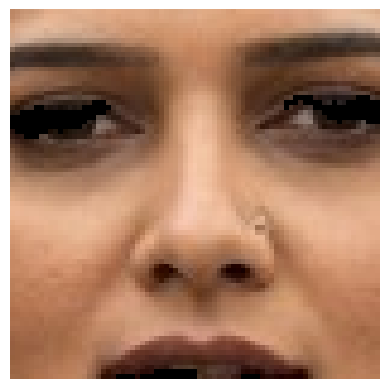

In [2]:
# Install OpenCV in this environment then import it

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Note: This notebook was designed for Google Colab
# For local use, provide your image path directly:
# Replace the following lines with your local image file

# from google.colab import files
# uploaded = files.upload()
# img = cv2.imread(list(uploaded.keys())[0])

# EXAMPLE - Replace with your actual image file path:
img_path = "F:\\We2\\fashion-ai-researchWork\\imagesForTesting\\Gemini_Generated_Image_wm2q4lwm2q4lwm2.jpeg"  # Update this path
img = cv2.imread(img_path)
if img is None:
    print(f"Error: Could not read image from {img_path}. Please provide a valid image path.")
else:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.axis('off')

    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    )

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(100, 100)
    )

    debug = img.copy()

    for (x, y, w, h) in faces:
        cv2.rectangle(debug, (x, y), (x+w, y+h), (0,255,0), 2)

    plt.imshow(debug)
    plt.axis("off")

    if len(faces) > 0:
        x, y, w, h = faces[0]

        # Crop central face area
        skin_region = img[
            y + int(0.25*h) : y + int(0.75*h),
            x + int(0.25*w) : x + int(0.75*w)
        ]

        plt.imshow(skin_region)
        plt.axis("off")


        lab = cv2.cvtColor(skin_region, cv2.COLOR_RGB2LAB)

        hsv = cv2.cvtColor(skin_region, cv2.COLOR_RGB2HSV)

        lower_skin = np.array([0, 20, 70], dtype=np.uint8)
        upper_skin = np.array([20, 255, 255], dtype=np.uint8)

        mask = cv2.inRange(hsv, lower_skin, upper_skin)

        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        mask = cv2.erode(mask, kernel, iterations=1)
        mask = cv2.dilate(mask, kernel, iterations=2)

        skin_only = cv2.bitwise_and(skin_region, skin_region, mask=mask)

        plt.imshow(skin_only)
        plt.axis("off")

        lab = cv2.cvtColor(skin_only, cv2.COLOR_RGB2LAB)

        L, A, B = cv2.split(lab)

        skin_pixels = mask > 0

        avg_L = np.mean(L[skin_pixels])
        avg_A = np.mean(A[skin_pixels])
        avg_B = np.mean(B[skin_pixels])

        print(f"Average LAB values: L={avg_L:.2f}, A={avg_A:.2f}, B={avg_B:.2f}")
    else:
        print("No faces detected in the image.")
